# Air Quality Impact — Data Centers & Residential Quality of Life

Measures ambient air quality trends across four data center case study counties
using EPA AQS annual data (2001–present). Pollutants chosen:

- **PM2.5** — fine particulate from diesel combustion (backup generators); most direct health impact metric
- **PM10** — coarse particulate matter (dust, construction); dominant in Arizona due to desert geography
- **NO2** — NOx proxy for combustion sources including diesel generators and power plants
- **Ozone** — secondary pollutant formed when NOx reacts with sunlight and heat; hardest to control

| Region | County | Utility | Boom cutpoint | Rationale |
|---|---|---|---|---|
| Virginia (VA) | Loudoun Co. | Dominion Energy | 2018 | Loudoun zoning fast-track; DC density surges |
| Arizona (AZ) | Maricopa Co. | APS + SRP | 2020 | Post-COVID hyperscale buildout begins |
| Ohio (OH) | Franklin Co. | AEP Ohio | 2020 | DC load climbs ~100 MW → 600 MW by 2024 |
| Oregon (OR) | Washington Co. | Portland General Electric | 2022 | PGE rate spiral begins |

**Data source:** EPA Air Quality System (AQS) pre-generated annual files

In [11]:
from pathlib import Path
import io, zipfile, warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

warnings.filterwarnings('ignore')

RAW_DIR  = Path('../data/air_quality/raw')
PROC_DIR = Path('../data/air_quality/processed')
FIG_DIR  = Path('../figures/air_quality')
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Match electricity notebook constants exactly
COLORS = {'VA': '#1f77b4', 'AZ': '#d62728', 'OH': '#2ca02c', 'OR': '#9467bd'}
BOOM   = {'VA': 2018, 'AZ': 2020, 'OH': 2020, 'OR': 2022}
STATE_LABEL = {'VA': 'Virginia (Loudoun Co.)', 'AZ': 'Arizona (Maricopa Co.)',
               'OH': 'Ohio (Franklin Co.)',    'OR': 'Oregon (Washington Co.)'}
STATE_ORDER = ['VA', 'AZ', 'OH', 'OR']

# County identifiers for EPA AQS files
# AQI-by-county uses name strings; concentration file uses FIPS codes
AQI_COUNTIES = {
    'VA': ('Virginia', 'Loudoun'),
    'AZ': ('Arizona', 'Maricopa'),
    'OH': ('Ohio',    'Franklin'),
    'OR': ('Oregon',  'Washington'),
}
FIPS_COUNTIES = {
    'VA': ('51', '107'),
    'AZ': ('04', '013'),
    'OH': ('39', '049'),
    'OR': ('41', '067'),
}

POLL_CODES    = {'88101': 'PM2.5', '42602': 'NO2', '44201': 'Ozone'}
POLL_STANDARD = {
    'PM2.5': 'PM25 Annual 2012',   # annual mean µg/m³
    'NO2':   'NO2 Annual 1971',    # annual mean ppb
    'Ozone': 'Ozone 8-Hour 2008',  # 8-hr daily max, convert ppm → ppb
}
NAAQS = {
    'PM2.5': (9,  'µg/m³'),
    'NO2':   (53, 'ppb'),
    'Ozone': (70, 'ppb'),
}

YEARS = list(range(2001, 2026))

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 120

## Part 1 — Data
### 1.1 Download raw files from EPA AQS

In [12]:
def _read_zip_csv(url):
    r = requests.get(url, timeout=180)
    if r.status_code != 200:
        return None
    with zipfile.ZipFile(io.BytesIO(r.content)) as z:
        csvs = [n for n in z.namelist() if n.endswith('.csv')]
        if not csvs:
            return None
        with z.open(csvs[0]) as f:
            df = pd.read_csv(f, dtype=str)
    df.columns = [c.strip() for c in df.columns]
    return df


def fetch_aqi_by_county():
    out = RAW_DIR / 'epa_aqi_by_county.csv'
    if out.exists():
        print('  epa_aqi_by_county.csv: already exists, skipping')
        return
    frames = []
    for year in YEARS:
        url = f'https://aqs.epa.gov/aqsweb/airdata/annual_aqi_by_county_{year}.zip'
        print(f'  AQI {year} ...', end=' ', flush=True)
        df = _read_zip_csv(url)
        if df is None:
            print('skip')
            continue
        mask = pd.Series(False, index=df.index)
        for abbr, (state, county) in AQI_COUNTIES.items():
            mask |= (df['State'] == state) & (df['County'] == county)
        sub = df[mask].copy()
        rev_map = {v: k for k, v in AQI_COUNTIES.items()}
        sub['state_abbr'] = sub.apply(lambda r: rev_map.get((r['State'], r['County']), ''), axis=1)
        frames.append(sub)
        print('ok')
    pd.concat(frames, ignore_index=True).to_csv(out, index=False)
    print(f'  → epa_aqi_by_county.csv: {sum(len(f) for f in frames)} rows')


def fetch_pollutant_concentrations():
    out = RAW_DIR / 'epa_pollutant_annual.csv'
    if out.exists():
        print('  epa_pollutant_annual.csv: already exists, skipping')
        return
    frames = []
    for year in YEARS:
        url = f'https://aqs.epa.gov/aqsweb/airdata/annual_conc_by_monitor_{year}.zip'
        print(f'  Conc {year} ...', end=' ', flush=True)
        df = _read_zip_csv(url)
        if df is None:
            print('skip')
            continue
        df = df[df['Parameter Code'].isin(POLL_CODES)].copy()
        mask = pd.Series(False, index=df.index)
        for abbr, (sc, cc) in FIPS_COUNTIES.items():
            mask |= (df['State Code'].str.zfill(2) == sc.zfill(2)) & \
                    (df['County Code'].str.zfill(3) == cc.zfill(3))
        sub = df[mask].copy()
        rev_map = {v: k for k, v in FIPS_COUNTIES.items()}
        sub['state_abbr'] = sub.apply(
            lambda r: rev_map.get((r['State Code'].zfill(2), r['County Code'].zfill(3)), ''), axis=1
        )
        sub['Pollutant'] = sub['Parameter Code'].map(POLL_CODES)
        frames.append(sub)
        print('ok')
    pd.concat(frames, ignore_index=True).to_csv(out, index=False)
    print(f'  → epa_pollutant_annual.csv: {sum(len(f) for f in frames)} rows')

In [13]:
print('[1/2] Annual AQI by county')
fetch_aqi_by_county()

print('\n[2/2] Annual concentration by monitor')
fetch_pollutant_concentrations()

print('\nDone.')

[1/2] Annual AQI by county
  epa_aqi_by_county.csv: already exists, skipping

[2/2] Annual concentration by monitor
  epa_pollutant_annual.csv: already exists, skipping

Done.


### 1.2 Load & process

In [14]:
# ── AQI ──────────────────────────────────────────────────────────────────────
aqi = pd.read_csv(RAW_DIR / 'epa_aqi_by_county.csv')
num_cols = ['Days with AQI','Good Days','Moderate Days',
            'Unhealthy for Sensitive Groups Days','Unhealthy Days',
            'Very Unhealthy Days','Hazardous Days',
            'Max AQI','90th Percentile AQI','Median AQI',
            'Days CO','Days NO2','Days Ozone','Days PM2.5','Days PM10']
for c in num_cols:
    aqi[c] = pd.to_numeric(aqi[c], errors='coerce')
aqi['Year'] = aqi['Year'].astype(int)
aqi['Bad Days'] = (aqi['Unhealthy for Sensitive Groups Days'] +
                   aqi['Unhealthy Days'] + aqi['Very Unhealthy Days'] +
                   aqi['Hazardous Days'])

# ── Pollutant concentrations ──────────────────────────────────────────────────
poll = pd.read_csv(RAW_DIR / 'epa_pollutant_annual.csv')
poll['Year'] = pd.to_numeric(poll['Year'], errors='coerce')
poll['Arithmetic Mean'] = pd.to_numeric(poll['Arithmetic Mean'], errors='coerce')

def get_pollutant(name, scale=1.0):
    std = POLL_STANDARD[name]
    sub = poll[(poll['Pollutant'] == name) & (poll['Pollutant Standard'] == std)].copy()
    sub['Value'] = sub['Arithmetic Mean'] * scale
    return sub.groupby(['state_abbr', 'Year'], as_index=False)['Value'].mean()

pm25  = get_pollutant('PM2.5')
no2   = get_pollutant('NO2')
ozone = get_pollutant('Ozone', scale=1000.0)  # ppm → ppb

print(f'AQI rows      : {len(aqi)}')
print(f'PM2.5 rows    : {len(pm25)}')
print(f'NO2 rows      : {len(no2)}')
print(f'Ozone rows    : {len(ozone)}')
print(f'Year range    : {aqi["Year"].min()} – {aqi["Year"].max()}')

AQI rows      : 100
PM2.5 rows    : 100
NO2 rows      : 75
Ozone rows    : 92
Year range    : 2001 – 2025


---
## Part 2 — Analysis

Three figures examining air quality as a quality-of-life factor in data center
case study regions (2001–2024):

1. **PM2.5 trend** — are residents breathing air near or above federal health limits?
2. **AQI composition** — which pollutants drive bad air days, and is diesel-linked PM2.5 growing?
3. **Bad air day heatmap** — how many days per year was air unhealthy, and how does that map onto data center growth periods?

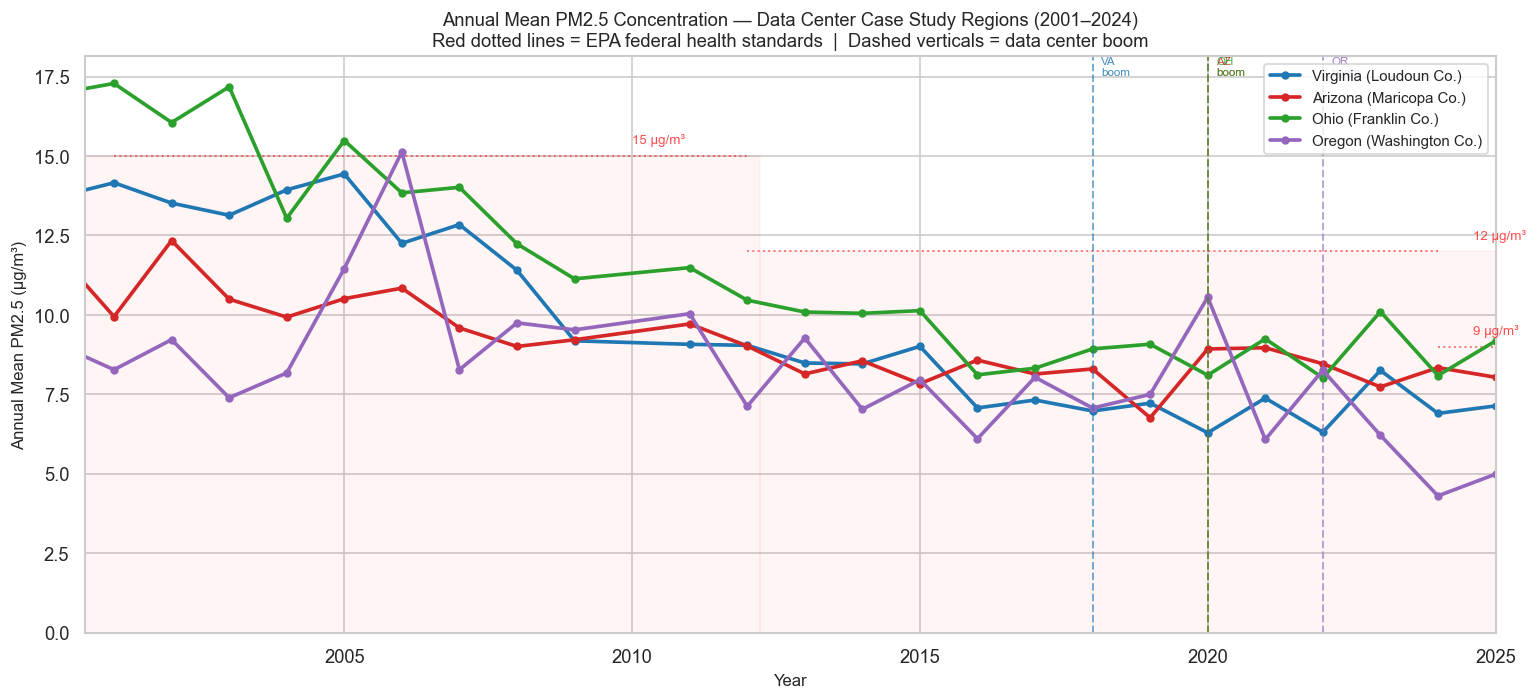

In [15]:
fig, ax = plt.subplots(figsize=(13, 6))

# NAAQS threshold steps
naaqs_steps = [(2001, 2012, 15, '15 µg/m³ (pre-2012)'),
               (2012, 2024, 12, '12 µg/m³ (2012–2024)'),
               (2024, 2025, 9,  '9 µg/m³ (2024–)')]

for y0, y1, val, lbl in naaqs_steps:
    ax.axhspan(0, val, xmin=(y0-2001)/23, xmax=min((y1-2001)/23, 1),
               color='red', alpha=0.04)
    ax.hlines(val, y0, min(y1, 2025), color='red', lw=1.2, ls=':', alpha=0.5)

# Region lines
for abbr in STATE_ORDER:
    df = pm25[pm25['state_abbr'] == abbr].sort_values('Year')
    ax.plot(df['Year'], df['Value'], color=COLORS[abbr], lw=2.2,
            marker='o', ms=4, label=STATE_LABEL[abbr])

# Boom lines — colored to match region, labeled at top
for abbr in STATE_ORDER:
    boom = BOOM[abbr]
    ax.axvline(boom, color=COLORS[abbr], lw=1.2, ls='--', alpha=0.6)
    ax.text(boom + 0.15, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 17,
            f'{abbr}\nboom', fontsize=7, color=COLORS[abbr], va='top', alpha=0.85)

# NAAQS labels on right
ax.text(2024.6, 9.3,  '9 µg/m³',  fontsize=8, color='red', alpha=0.7, va='bottom')
ax.text(2024.6, 12.3, '12 µg/m³', fontsize=8, color='red', alpha=0.7, va='bottom')
ax.text(2010,   15.3, '15 µg/m³', fontsize=8, color='red', alpha=0.7, va='bottom')

ax.set_xlim(2000.5, 2025)
ax.set_ylim(bottom=0)
ax.set_xlabel('Year', fontsize=10)
ax.set_ylabel('Annual Mean PM2.5 (µg/m³)', fontsize=10)
ax.set_title('Annual Mean PM2.5 Concentration — Data Center Case Study Regions (2001–2024)\n'
             'Red dotted lines = EPA federal health standards  |  Dashed verticals = data center boom',
             fontsize=11)
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout()
fig.savefig('../data/air_quality/processed/fig1_pm25_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

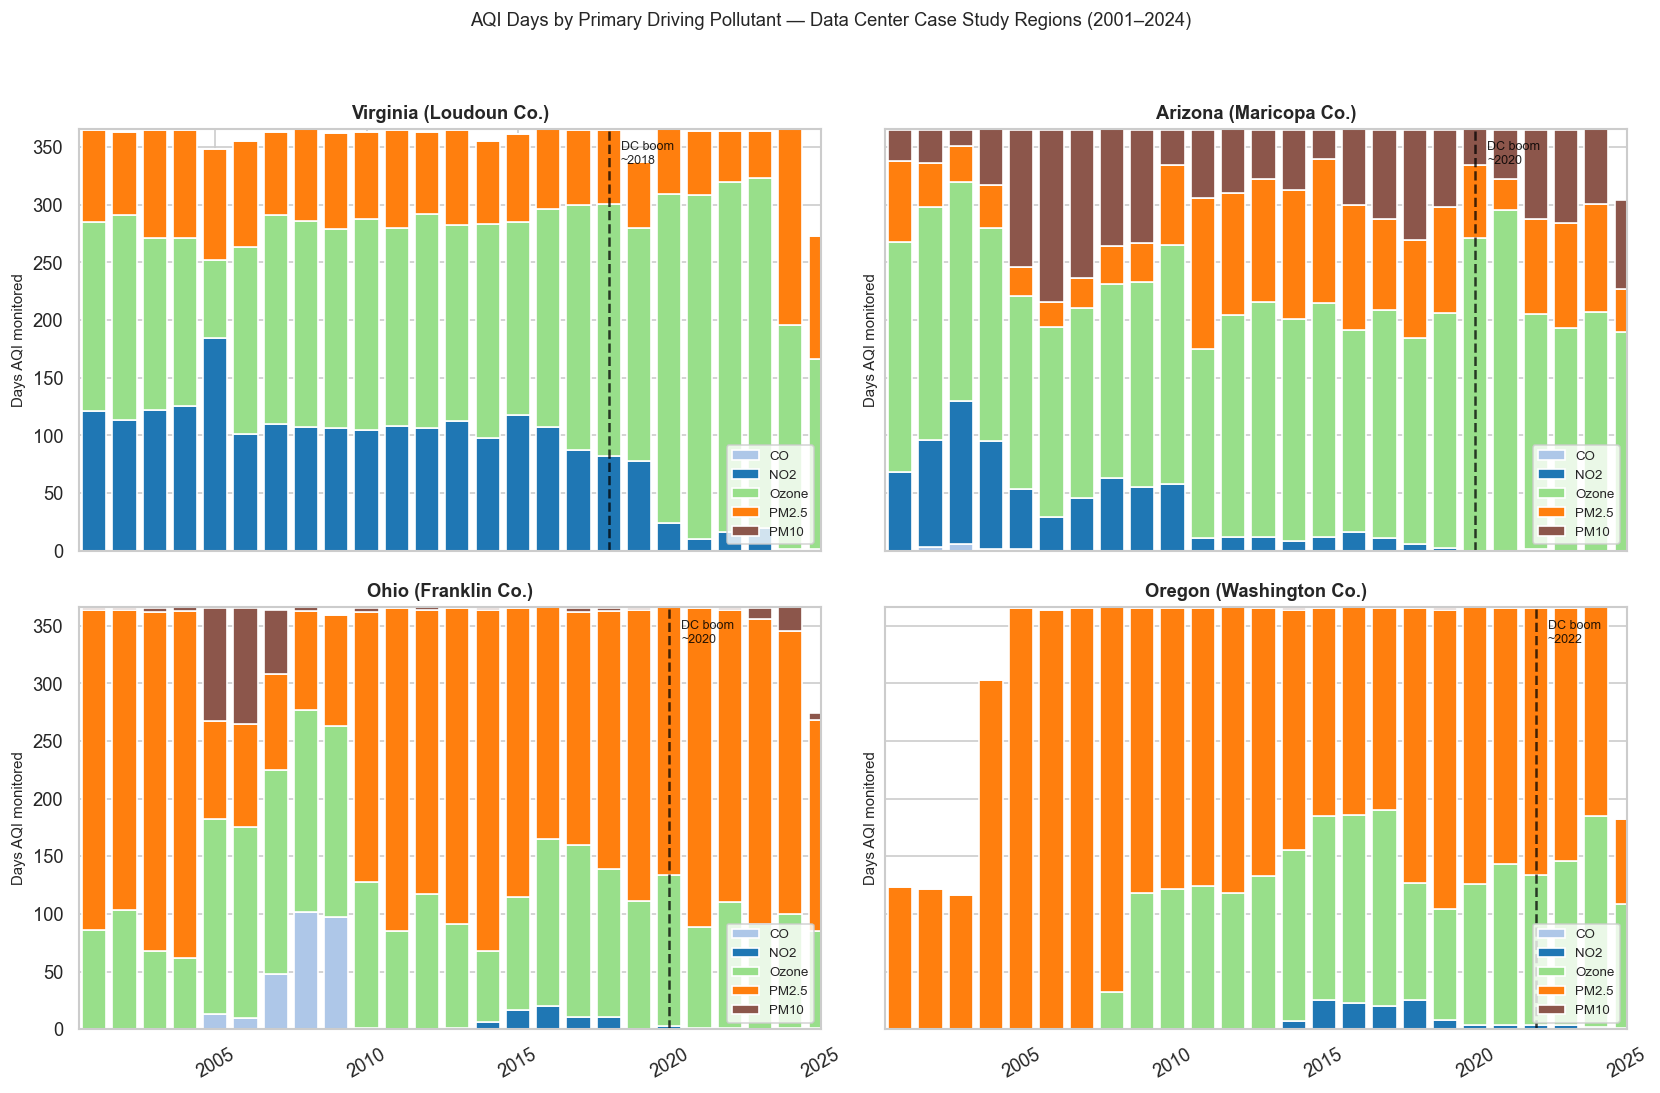

In [16]:
driver_cols   = ['Days CO', 'Days NO2', 'Days Ozone', 'Days PM2.5', 'Days PM10']
driver_colors = ['#aec7e8', '#1f77b4',  '#98df8a',    '#ff7f0e',    '#8c564b']
driver_labels = ['CO',      'NO2',      'Ozone',      'PM2.5',      'PM10']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)

for ax, abbr in zip(axes.flatten(), STATE_ORDER):
    df = aqi[aqi['state_abbr'] == abbr].sort_values('Year')
    bottom = np.zeros(len(df))
    for col, color, lbl in zip(driver_cols, driver_colors, driver_labels):
        vals = df[col].fillna(0).values
        ax.bar(df['Year'], vals, bottom=bottom, color=color, label=lbl, width=0.8)
        bottom += vals

    boom = BOOM[abbr]
    ax.axvline(boom, color='black', lw=1.5, ls='--', alpha=0.75)
    ymax = df[driver_cols].sum(axis=1).max()
    ax.text(boom + 0.4, ymax * 0.97, f'DC boom\n~{boom}',
            fontsize=7.5, va='top', color='black', alpha=0.85)

    ax.set_title(STATE_LABEL[abbr], fontsize=11, fontweight='bold')
    ax.set_ylabel('Days AQI monitored', fontsize=9)
    ax.set_xlim(2000.5, 2025)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('AQI Days by Primary Driving Pollutant — Data Center Case Study Regions (2001–2024)\n',
             fontsize=11, y=1.01)
fig.tight_layout()
fig.savefig('../data/air_quality/processed/fig2_aqi_composition.png', dpi=150, bbox_inches='tight')
plt.show()

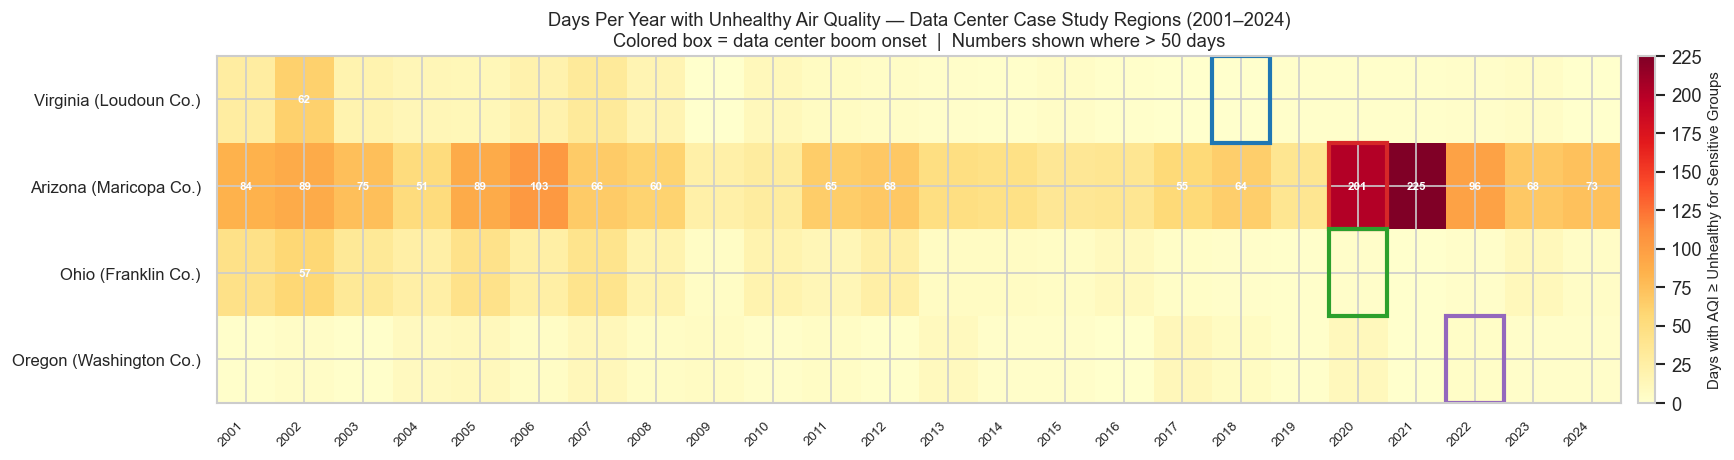

In [17]:
pivot = aqi[aqi['Year'] <= 2024].pivot(index='state_abbr', columns='Year', values='Bad Days')
pivot = pivot.loc[STATE_ORDER]
row_labels = [STATE_LABEL[s] for s in STATE_ORDER]

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns.astype(int), rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(4))
ax.set_yticklabels(row_labels, fontsize=10)

# Boom year boxes, colored to match region
for i, abbr in enumerate(STATE_ORDER):
    col_idx = list(pivot.columns).index(BOOM[abbr])
    ax.add_patch(plt.Rectangle((col_idx - 0.5, i - 0.5), 1, 1,
                                fill=False, edgecolor=COLORS[abbr], lw=2.5))

# Value annotations for cells above 50 days
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not np.isnan(val) and val > 50:
            ax.text(j, i, str(int(val)), ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

cbar = fig.colorbar(im, ax=ax, pad=0.01)
cbar.set_label('Days with AQI ≥ Unhealthy for Sensitive Groups', fontsize=9)
ax.set_title("Days Per Year with Unhealthy Air Quality — Data Center Case Study Regions (2001–2024)\n"
             "Colored box = data center boom onset  |  Numbers shown where > 50 days",
             fontsize=11)
fig.tight_layout()
fig.savefig('../data/air_quality/processed/fig3_unhealthy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
import shutil
from pathlib import Path

VIZ_DIR = Path('../visualizations')
VIZ_DIR.mkdir(exist_ok=True)

prefix = 'air_quality'
for png in sorted(PROC_DIR.glob('*.png')):
    dest = VIZ_DIR / f'air_quality_{png.name}'
    shutil.copy2(png, dest)
    print(f'  → {dest.name}')
print(f'Exported {len(list(PROC_DIR.glob("*.png")))} figures to visualizations/')

  → air_quality_fig1_pm25_overlay.png
  → air_quality_fig2_aqi_composition.png
  → air_quality_fig3_unhealthy_heatmap.png
Exported 3 figures to visualizations/
